# TechMart Q1 2026 Sales Report

**Analytics Team** | January 2026

---

In [1]:
import warnings
warnings.filterwarnings('ignore')

import os, pandas as pd, matplotlib.pyplot as plt
from urllib.parse import quote_plus
from dotenv import load_dotenv
from sqlalchemy import create_engine

pd.set_option('display.float_format', '{:,.2f}'.format)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

load_dotenv()
DB_URL = f"postgresql://{os.getenv('DB_USER')}:{quote_plus(os.getenv('DB_PASSWORD'))}@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT', '5432')}/{os.getenv('DB_NAME')}"
engine = create_engine(DB_URL)

%reload_ext sql
%config SqlMagic.displaylimit = 20
%config SqlMagic.autopandas = True
%sql engine --alias postgres
print('Ready.')

Tip: You may define configurations in /home/jupyter/notebooks/pyproject.toml or /home/jupyter/.jupysql/config.

Did not find user configurations in /home/jupyter/notebooks/pyproject.toml.

Ready.


## 1. KPIs

In [2]:
%%sql
SELECT COUNT(DISTINCT o.id) AS orders, COUNT(DISTINCT o.customer_id) AS customers,
    ROUND(SUM(o.quantity * p.price)::numeric, 2) AS revenue
FROM orders o JOIN products p ON o.product_id = p.id

Running query in 'postgres'

1 rows affected.

,orders,customers,revenue
0,20,10,17619.69


## 2. Revenue by Category

In [3]:
df_cat = %sql SELECT p.category, ROUND(SUM(o.quantity * p.price)::numeric, 2) AS revenue FROM orders o JOIN products p ON o.product_id = p.id GROUP BY p.category ORDER BY revenue DESC
df_cat

Running query in 'postgres'

3 rows affected.

,category,revenue
0,Electronics,13199.89
1,Accessories,3069.83
2,Gaming,1349.97


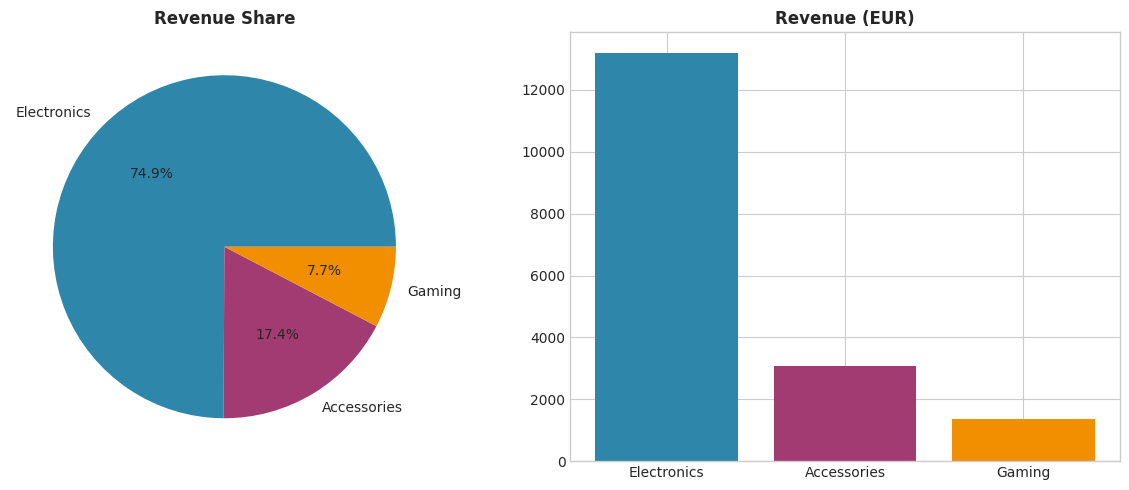

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].pie(df_cat['revenue'], labels=df_cat['category'], autopct='%1.1f%%', colors=['#2E86AB', '#A23B72', '#F18F01'])
ax[0].set_title('Revenue Share', fontweight='bold')
ax[1].bar(df_cat['category'], df_cat['revenue'], color=['#2E86AB', '#A23B72', '#F18F01'])
ax[1].set_title('Revenue (EUR)', fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Revenue by City

In [5]:
df_city = %sql SELECT c.city, ROUND(SUM(o.quantity * p.price)::numeric, 2) AS revenue FROM customers c JOIN orders o ON c.id = o.customer_id JOIN products p ON o.product_id = p.id GROUP BY c.city ORDER BY revenue DESC
df_city

Running query in 'postgres'

6 rows affected.

,city,revenue
0,Paris,6549.93
1,Barcelona,4699.90
2,Milan,3249.95
3,London,1769.94
4,Berlin,849.98
5,Madrid,499.99


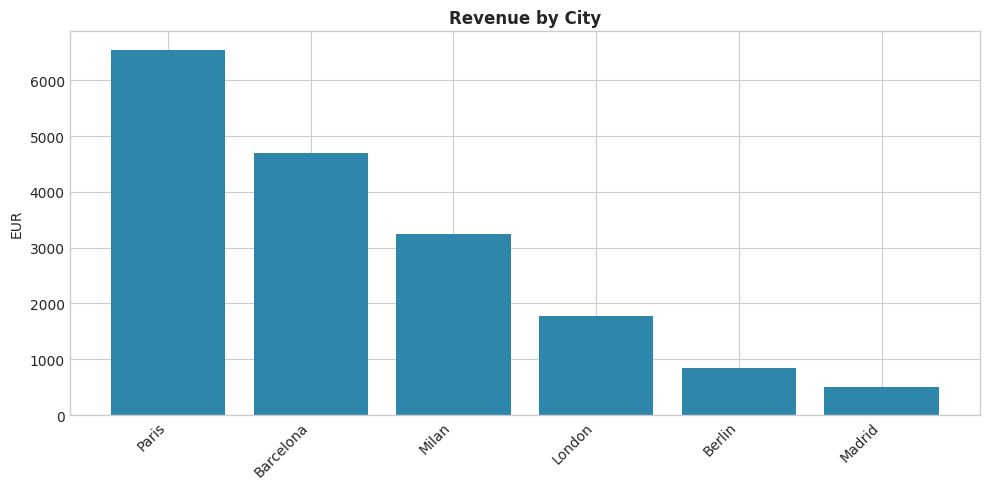

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(df_city['city'], df_city['revenue'], color='#2E86AB')
ax.set_title('Revenue by City', fontweight='bold')
ax.set_ylabel('EUR')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 4. Customer Tiers

In [7]:
%%sql
WITH cv AS (
    SELECT c.name, COALESCE(SUM(o.quantity * p.price), 0) AS spent
    FROM customers c LEFT JOIN orders o ON c.id = o.customer_id
    LEFT JOIN products p ON o.product_id = p.id GROUP BY c.id, c.name
)
SELECT name, ROUND(spent::numeric, 2) AS total_spent,
    CASE WHEN spent >= 2000 THEN 'Platinum' WHEN spent >= 1000 THEN 'Gold'
         WHEN spent > 0 THEN 'Silver' ELSE 'Inactive' END AS tier
FROM cv ORDER BY spent DESC

Running query in 'postgres'

11 rows affected.

,name,total_spent,tier
0,Marie Dupont,5349.94,Platinum
1,Ana Garcia,4099.91,Platinum
2,Marco Bianchi,2249.98,Platinum
3,John Smith,1299.98,Gold
4,Pierre Martin,1199.99,Gold
5,Sofia Rossi,999.97,Silver
6,Hans Mueller,849.98,Silver
7,Laura Sanchez,599.99,Silver
8,Carlos Lopez,499.99,Silver
9,Emma Wilson,469.96,Silver


## 5. Top Products

Running query in 'postgres'

6 rows affected.

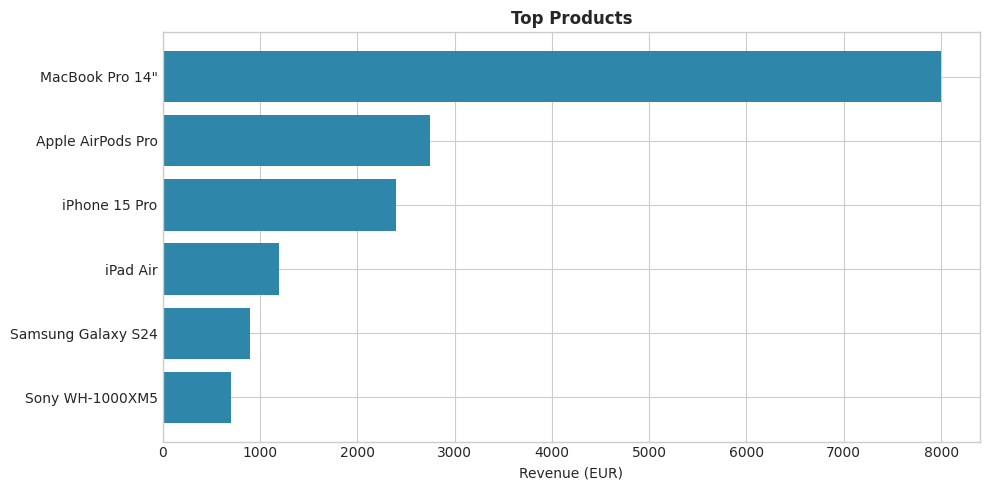

In [8]:
df_top = %sql SELECT p.name, ROUND(SUM(o.quantity * p.price)::numeric, 2) AS revenue FROM products p JOIN orders o ON p.id = o.product_id GROUP BY p.id, p.name ORDER BY revenue DESC LIMIT 6

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(df_top['name'][::-1], df_top['revenue'][::-1], color='#2E86AB')
ax.set_xlabel('Revenue (EUR)')
ax.set_title('Top Products', fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Order Trends

Running query in 'postgres'

19 rows affected.

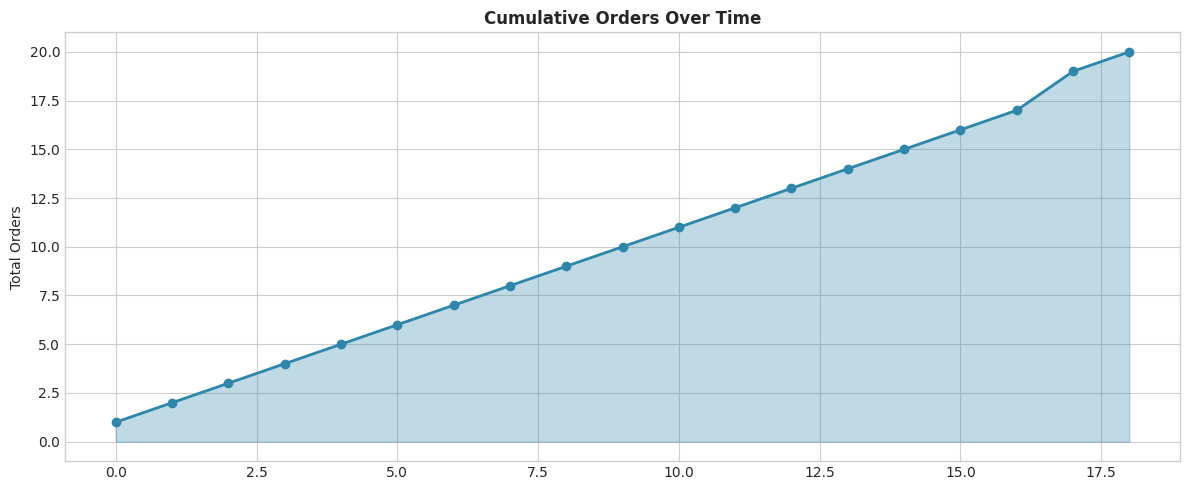

In [9]:
df_daily = %sql SELECT order_date, COUNT(*) AS orders, SUM(COUNT(*)) OVER (ORDER BY order_date) AS cumulative FROM orders GROUP BY order_date ORDER BY order_date

fig, ax = plt.subplots(figsize=(12, 5))
ax.fill_between(range(len(df_daily)), df_daily['cumulative'], alpha=0.3, color='#2E86AB')
ax.plot(df_daily['cumulative'], marker='o', color='#2E86AB', linewidth=2)
ax.set_title('Cumulative Orders Over Time', fontweight='bold')
ax.set_ylabel('Total Orders')
plt.tight_layout()
plt.show()

## 7. Inventory Alerts

In [10]:
%%sql
SELECT p.name, p.stock, COALESCE(SUM(o.quantity), 0) AS sold,
    CASE WHEN p.stock <= 20 THEN 'CRITICAL' WHEN p.stock <= 50 THEN 'Warning' ELSE 'OK' END AS status
FROM products p LEFT JOIN orders o ON p.id = o.product_id
GROUP BY p.id, p.name, p.stock HAVING p.stock <= 50 ORDER BY p.stock

Running query in 'postgres'

8 rows affected.

,name,stock,sold,status
0,Old Product,0,0,CRITICAL
1,PlayStation 5,15,1,CRITICAL
2,Xbox Series X,20,1,CRITICAL
3,"MacBook Pro 14""",25,4,Warning
4,iPad Air,35,2,Warning
5,Samsung Galaxy S24,40,1,Warning
6,Nintendo Switch OLED,45,1,Warning
7,iPhone 15 Pro,50,2,Warning


---
## Summary

| Insight | Action |
|---------|--------|
| Electronics = 75% revenue | Expand line |
| Paris top city | VIP program |
| PS5 low stock | Restock urgently |

*Generated with PostgreSQL + Jupyter*